In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import datetime as dt
import re
import os

In [2]:
# File paths
file_names = [r"data\firsttest_test_data_20251128_095740.csv",
            #   r"data\newdata_test_data_20251128_115950.csv",
            #   r"data\5blade_test_data_20251128_120814.csv",
            #   r"data\11blade_test_data_20251128_121726.csv",
              ]

In [3]:
# Useful functions
def datetime_conversion(timestamp):
    timestamp = timestamp[:-4]
    return dt.datetime.strptime(timestamp,'%Y-%m-%d %H:%M:%S')
def moving_average(data, window_size=5):
    """Calculate moving average of data"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [4]:
# Extraction of data
fan_results = []
flowcoeffs = []
flowcoeffs_errors = []
prisecoeffs = []
prisecoeffs_errors = []
avgSpeeds = []
dpventuris = []
dpventuris_errors = []
dpstages = []
dpstages_errors = []

times = pd.read_csv(file_names[0])['timestamp'].apply(datetime_conversion)
rel_times = (times - times.iloc[0]).dt.total_seconds()

for i, f in enumerate(file_names):
    fan_results.append(pd.read_csv(f))
    avgSpeeds.append(np.mean(fan_results[i]['rpm_mean']))

In [3]:
# Label generation regex
re_expression = r"([0-9]+blade)"
re_expression2 = r"(?<=data\\)([a-z0-9]+)(?=_test)"
labels = [re.search(re_expression2,f).group(0)+ f" (Avg RPM: {avgSpeeds[i]:.1f})" for i,f in enumerate(file_names)]

NameError: name 'file_names' is not defined

## Pressure Plot

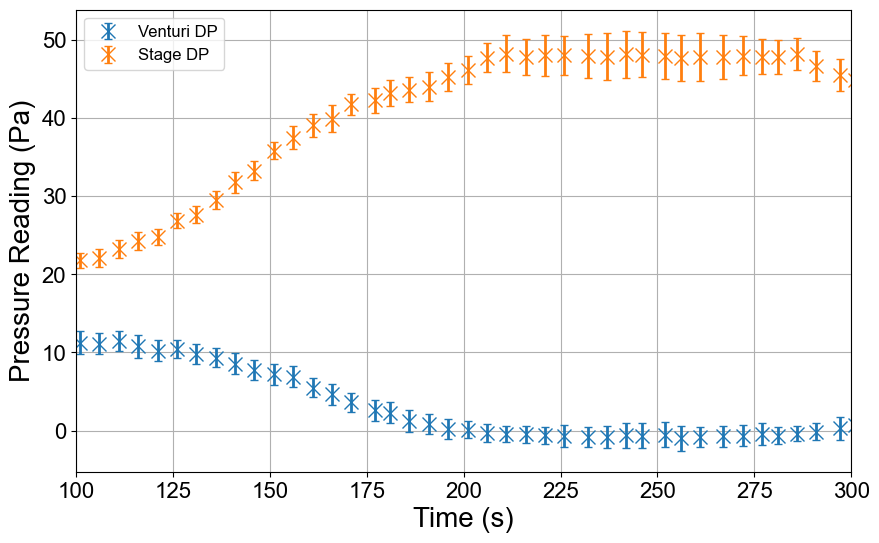

In [11]:
plt.style.use('presentation.mplstyle')
fig1,ax1 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    if i!=2:
        continue
    ax1.errorbar(rel_times, r['dp_venturi_mean'], yerr=r['dp_venturi_stddev'],label=f"Venturi DP", **errorbar_format)
    ax1.errorbar(rel_times, r['dp_stage_mean'], yerr=r['dp_stage_stddev'], label=f"Stage DP", **errorbar_format)
ax1.set_xlabel("Time (s)")
# ax1.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax1.set_ylabel("Pressure Reading (Pa)")
ax1.set_xlim(100,300)
ax1.legend()
ax1.grid()
# fig1.savefig("presentation/pressure_readings.svg", bbox_inches='tight')
plt.show()

## Axial Velocity and Mass flow

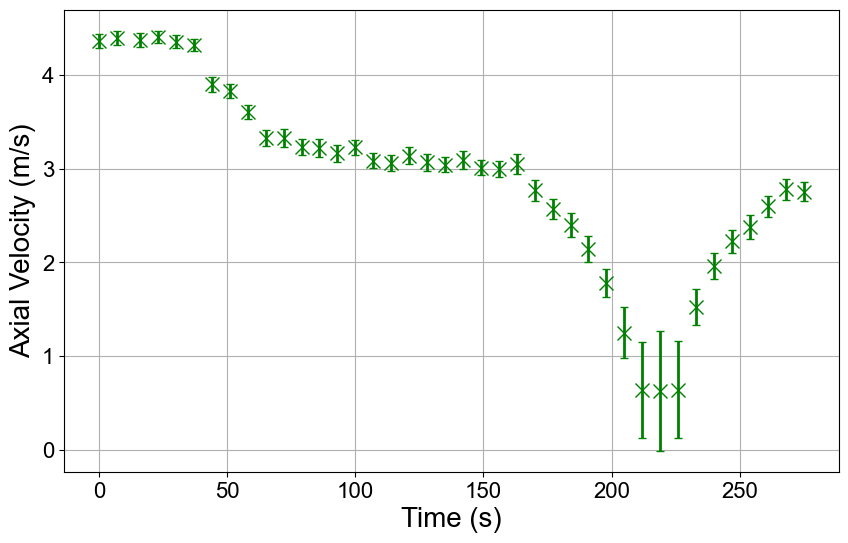

In [28]:
fig2,ax2 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    ax2.errorbar(rel_times, r['axvelocity_mean'], yerr=r['axvelocity_stddev'],label=f"Axial Velocity", color='g', **errorbar_format)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Axial Velocity (m/s)")
ax2.grid()
fig2.savefig("presentation/axial_velocity.svg", bbox_inches='tight')
plt.show()

## Flow Coeff vs Prise

In [2]:
# file_names = [r"data\5blade_test_data_20251128_123537.csv",
#               r"data\firsttest_test_data_20251128_095740.csv",
#               r"data\11blade_test_data_20251128_121726.csv",
#               ]
# file_names = [
#               r"data\firsttest_test_data_20251128_095740.csv",
#               r"data\retest_test_data_20251128_100251.csv",
#               r"data\rebuild_test_data_20251128_100917.csv",
#               ]
# file_names = [
#               r"data\stall_test_data_20251128_124500.csv",
#               ]


# file_names = [
#     r"data/test_data_20260217_154153.csv",
#     r"data/test_data_20260217_155610.csv",
#     r"data/test_data_20260217_160520.csv",
#     r"data/test_data_20260217_161501.csv",
#     r"data/test_data_20260217_162442.csv",
# ]

# file_names = [
#     r"data\test_data_rpmsweep_1500_7blade_20260223_165250.csv",
#     r"data\test_data_rpmsweep_2000_7blade_20260223_163214.csv",
#     r"data\test_data_rpmsweep_2500_7blade_20260223_162412.csv",
#     r"data\test_data_rpmsweep_3000_7blade_20260223_161246.csv",
#     r"data\test_data_rpmsweep_3500_7blade_20260223_160422.csv",
# ]

# file_names = [
#     r"data\test_data_doe_test_0_20260303_101955.csv",
#     # r"data\test_data_doe_test_1_20260303_102936.csv",
#     # r"data\test_data_doe_test_2_20260303_103942.csv",
#     # r"data\test_data_doe_test_3_20260303_104901.csv",
#     r"data\test_data_doe_test_4_20260303_105822.csv",
#     r"data\test_data_test_rig_0_20260311_120134.csv",
#     r"data\test_data_test rig 1_20260311_121604.csv",
#     r"data\test_data_test 0 fan outside_20260312_123233.csv",
#     r"data\test_data_repeat test 0_20260312_143544.csv"
# ]

file_names = [r"data\test_data_rig_testing_0_20260316_104031.csv",
              r"data\test_data_rig_testing_1_in_out_20260316_104702.csv",
              r"data\test_data_rig_testing_2_rebuild_20260316_105419.csv"]

In [12]:
# file_names = os.listdir(r"data\doe_data")
file_names = sorted(os.listdir(r"data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group()))

In [13]:
print(file_names)

['DOE_0_9.0_0.0743611981119211_0.8054925797873145_-4.38755814594996_-1.6759525583862622_3.126742035963525_1_14.287170525537093_3.057blade.csv', 'DOE_1_9.0_0.0446088650271294_0.8725729904497341_-1.6626277838160188_-1.4621235717692072_3.9317371102595375_1_30.92465705102048_1.478blade.csv', 'DOE_2_7.0_0.0495203562128305_0.8042340158049601_-9.839012890016615_-0.0836474397629409_1.613572586338451_1_67.97070004967647_2.616blade.csv', 'DOE_3_9.0_0.0437288949450894_0.7996993686217887_-6.665737144890572_-1.76796540269945_0.3942861865084435_1_38.81759201665001_3.432blade.csv', 'DOE_4_6.0_0.0277036408488363_0.8389460700697476_-0.4785073683565901_-1.9342083900219484_5.944124133156613_1_16.559395825444803_2.21blade.csv', 'DOE_5_8.0_0.0682380791576443_0.7965583362602342_-7.908941480741281_-1.422638333298462_9.337879183212362_1_54.95685038908963_4.146blade.csv', 'DOE_6_9.0_0.0640196363719874_0.8743330528311015_2.9458717041826787_-0.5173823849059791_4.783307914687606_1_25.7551274696601_3.04blade.csv',

In [14]:
param_values = pd.read_csv('doe_params.csv',index_col=None)
# param_values = [param_values.iloc[0],param_values.iloc[4]]

In [16]:
fan_results = []
avgSpeeds = []
for i, f in enumerate(file_names):
    fan_results.append(pd.read_csv(f"data/doe_data/{f}"))
    avgSpeeds.append(np.mean(fan_results[i]['rpm_mean']))
    
# labels = ["5 Blade", "7 Blade", "11 Blade"]
# labels = ["Test 1", "Test 2", "Test 3"]
# labels = ["stall 5 blade"]
# labels = ["Standard", "Shrouded", "3 Chevron", "5 Chevron", "7 Chevron"]
# labels = ['1500', '2000', '2500', '3000', '3500']
# labels = [f"Mdot:{row[1]:.3f}, DH:{row[2]:.2f}" for row in param_values.iloc[:5].itertuples()]+[f"test rig (same as Mdot:0.028, DH:0.84)",f"test rig (same as Mdot:0.074, DH:0.81)"]
# labels = [f"Mdot:{row.iloc[0]:.3f}, DH:{row.iloc[1]:.2f}" for row in param_values]+[f"test rig (same as Mdot:0.028, DH:0.84)",f"test rig (same as Mdot:0.074, DH:0.81)","repeat, outside box", "repeat test"]
# labels = ["initial", "in&out", "rebuild"]
print(param_values.head())
labels = [f"Idx: {i}, Mdot:{row["mdot"]:.3f}, DH:{row["DH_mid"]:.2f}" for i,row in param_values.iterrows()]

   Unnamed: 0      mdot    DH_mid  incidence      Vexp  lean_compound  \
0           0  0.074361  0.805493  -4.387558 -1.675953       3.126742   
1           1  0.044609  0.872573  -1.662628 -1.462124       3.931737   
2           2  0.049520  0.804234  -9.839013 -0.083647       1.613573   
3           3  0.043729  0.799699  -6.665737 -1.767965       0.394286   
4           4  0.027704  0.838946  -0.478507 -1.934208       5.944124   

   lean_straight  tip_clearance  n_blade  
0      14.287171       3.056605        9  
1      30.924657       1.477852        9  
2      67.970700       2.615517        7  
3      38.817592       3.431854        9  
4      16.559396       2.209822        6  


In [17]:
print(labels)

['Idx: 0, Mdot:0.074, DH:0.81', 'Idx: 1, Mdot:0.045, DH:0.87', 'Idx: 2, Mdot:0.050, DH:0.80', 'Idx: 3, Mdot:0.044, DH:0.80', 'Idx: 4, Mdot:0.028, DH:0.84', 'Idx: 5, Mdot:0.068, DH:0.80', 'Idx: 6, Mdot:0.064, DH:0.87', 'Idx: 7, Mdot:0.033, DH:0.88', 'Idx: 8, Mdot:0.032, DH:0.79', 'Idx: 9, Mdot:0.046, DH:0.85', 'Idx: 10, Mdot:0.063, DH:0.75', 'Idx: 11, Mdot:0.067, DH:0.82', 'Idx: 12, Mdot:0.035, DH:0.83', 'Idx: 13, Mdot:0.027, DH:0.90', 'Idx: 14, Mdot:0.047, DH:0.86', 'Idx: 15, Mdot:0.070, DH:0.85', 'Idx: 16, Mdot:0.069, DH:0.82', 'Idx: 17, Mdot:0.042, DH:0.76', 'Idx: 18, Mdot:0.071, DH:0.82', 'Idx: 19, Mdot:0.056, DH:0.85', 'Idx: 20, Mdot:0.068, DH:0.78', 'Idx: 21, Mdot:0.074, DH:0.86', 'Idx: 22, Mdot:0.055, DH:0.87', 'Idx: 23, Mdot:0.025, DH:0.85', 'Idx: 24, Mdot:0.054, DH:0.79', 'Idx: 25, Mdot:0.051, DH:0.76', 'Idx: 26, Mdot:0.038, DH:0.87', 'Idx: 27, Mdot:0.071, DH:0.82', 'Idx: 28, Mdot:0.067, DH:0.83', 'Idx: 29, Mdot:0.044, DH:0.87', 'Idx: 30, Mdot:0.041, DH:0.86', 'Idx: 31, Mdot:0.

In [18]:
for d in fan_results:
    # Calculation of 95% confidence intervals
    d["flowcoeff_confidence"] = 1.96 * d['flow_coefficient_stddev'] / np.sqrt(100)
    d["prisecoeff_confidence"] = 1.96 * d['pressure_rise_coefficient_stddev'] / np.sqrt(100)
    
    # Remove negative pressure readings
    for i, row in d.iterrows():
        if row['dp_venturi_mean'] < 0:
            d.drop(i, inplace=True)

In [19]:
colours = ['b','r','g','c','m','y','k']

In [20]:
plt.style.use('report.mplstyle')

In [21]:
row = param_values.iloc[80]
index = 80#row.Index
n_blades = row.n_blade
mdot = row.mdot
DHmid = row.DH_mid
INC = row.incidence
Vexp = row.Vexp
lean_max = row.lean_compound
lean_weighting = int(1.0)
lean_straight = row.lean_straight
tip_clearance_percent = np.round(row.tip_clearance,3)

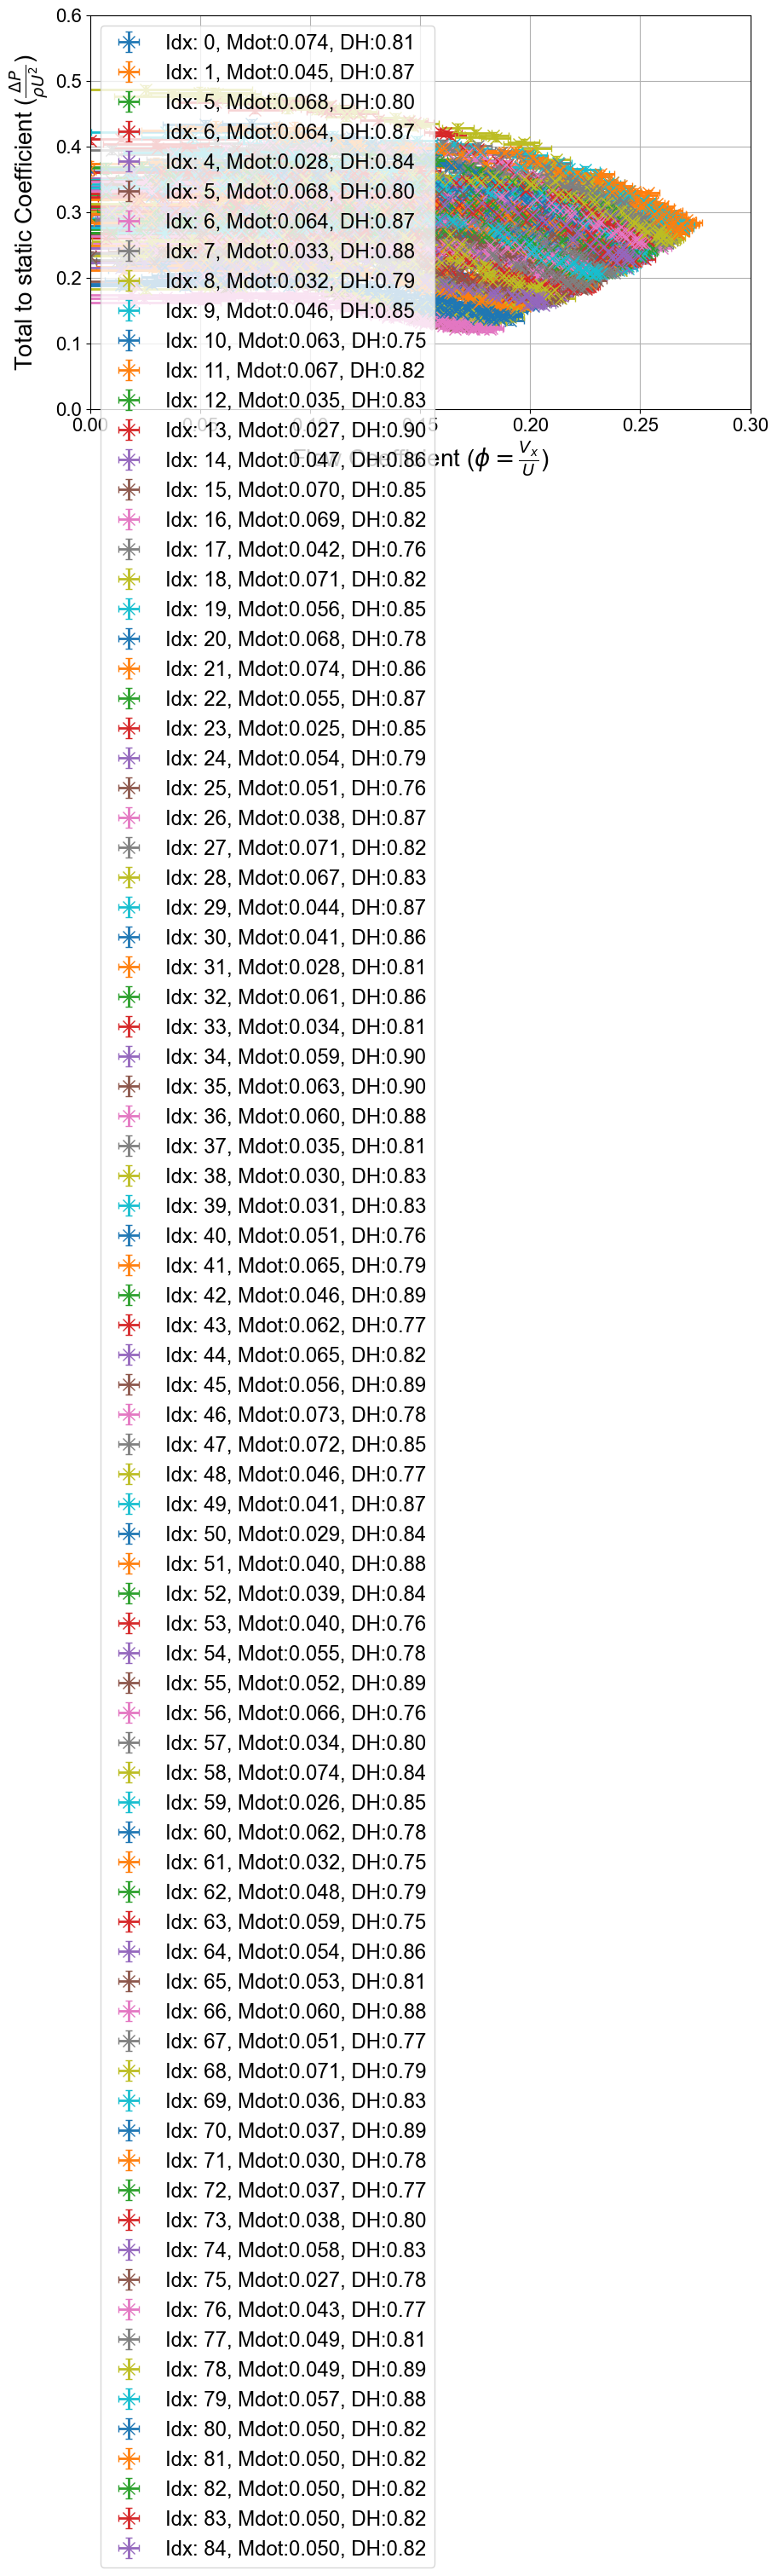

In [22]:
fig3,ax3 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    if i==2:
        i=5
    elif i==3:
        i=6
    
    # if i==index:
    #     pass
    # elif i>index-3 and i < index+3:
    #     pass
    # elif i==69:
    #     pass
    # else:
    #     continue
    ax3.errorbar(r['flow_coefficient_mean'], 
                 r['pressure_rise_coefficient_mean'], 
                 xerr=r['flowcoeff_confidence'], 
                 yerr=r['prisecoeff_confidence'], 
                 #color=colours[i], 
                 label = labels[i], **errorbar_format)
    # ax3.plot(r['flow_coefficient_mean'], r['efficiency_mean'],label = labels[i])
    
x = np.linspace(0,0.3,50)
k = 3.7
# ax3.plot(x,k*x*x,label = "system curve")
ax3.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax3.set_ylabel("Total to static Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)")
ax3.grid()
ax3.set_ylim(0,0.6)
ax3.set_xlim(0,0.3)
ax3.legend()
# fig3.savefig("report/repeat_fan_performance_curve.svg", bbox_inches='tight')
# fig3.savefig("report/fan_performance_curve_multi_fan.svg", bbox_inches='tight')
# fig3.savefig("report/repeat_confidence95_fan_performance_curve.svg", bbox_inches='tight')
plt.show()

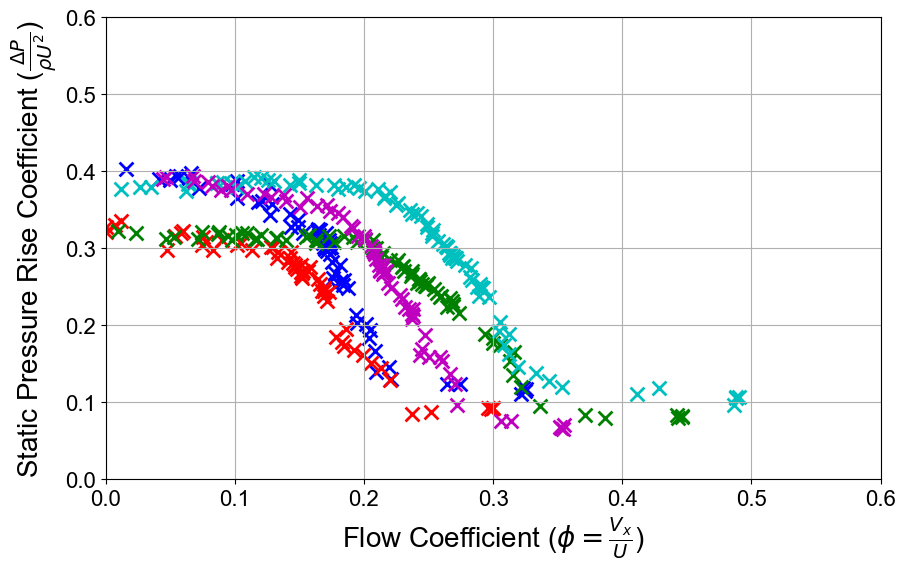

In [ ]:
fig32,ax32 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    ax32.scatter(r['flow_coefficient_mean'], 
                 r['pressure_rise_coefficient_mean'], 
                 color=colours[i], label = labels[i], marker='x')
ax32.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax32.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)")
ax32.grid()
ax32.set_ylim(0,0.6)
ax32.set_xlim(0,0.6)
# fig32.savefig("report/stall.svg", bbox_inches='tight')
plt.show()

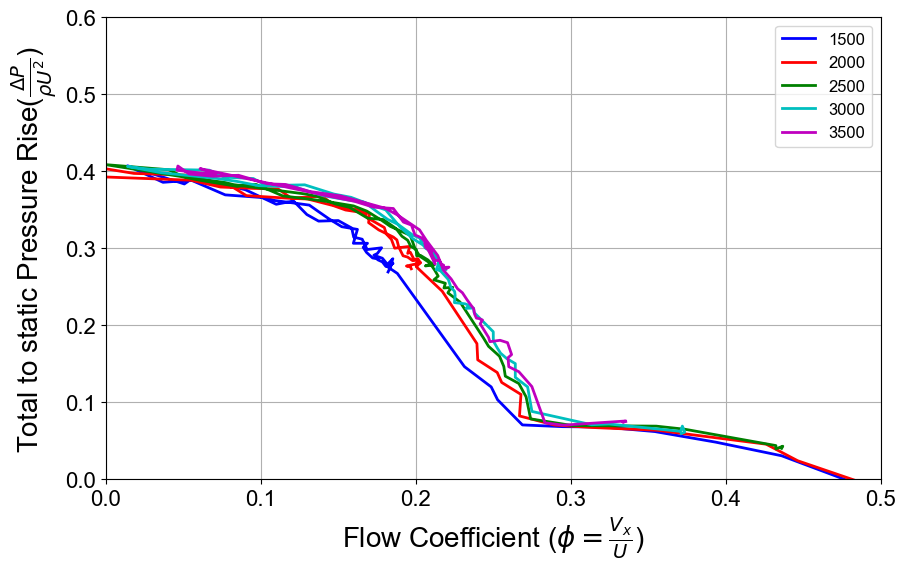

In [9]:
fig4,ax4 = plt.subplots(1,1,figsize=(10,6))
for i, r in enumerate(fan_results):
    ax4.plot(fan_results[i]['flow_coefficient_mean'], fan_results[i]['pressure_rise_coefficient_mean'], color=colours[i],label = labels[i])
ax4.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax4.set_ylabel("Total to static Pressure Rise($\\frac{\\Delta P}{\\rho U^2}$)")
ax4.grid()
ax4.set_ylim(0,0.6)
ax4.set_xlim(0,0.5)
ax4.legend()
# fig4.savefig("report/fan_performance_curve_multi_fan.svg", bbox_inches='tight')
plt.show()

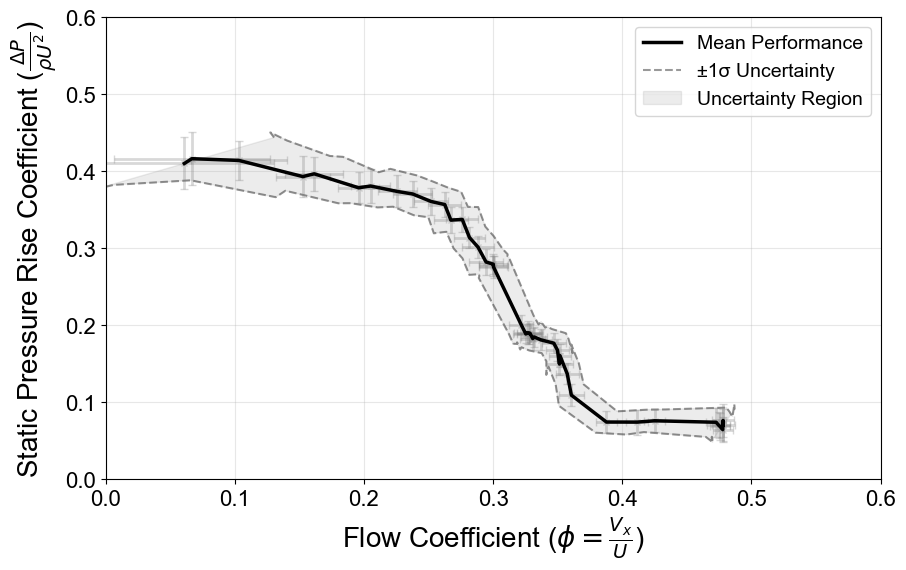

In [127]:
fig5, ax5 = plt.subplots(1, 1, figsize=(10, 6))

# Use the second dataset (retest) for detailed analysis
data = fan_results[1]

# Sort by flow coefficient
sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
prise_err_sorted = data['pressure_rise_coefficient_stddev'].values[sorted_indices]
flow_err_sorted = data['flow_coefficient_stddev'].values[sorted_indices]

# Plot main line
ax5.plot(flow_sorted, prise_sorted, 'k-', linewidth=2.5, label='Mean Performance', zorder=3)
#ax5.scatter(flow_sorted, prise_sorted,marker='x', color='k', label='Mean Performance')

# Create Pareto front envelope considering both x and y uncertainties
# Upper bound: (flow + flow_err, prise + prise_err)
# Lower bound: (flow - flow_err, prise - prise_err)
upper_flow = flow_sorted + flow_err_sorted
upper_prise = prise_sorted + prise_err_sorted
lower_flow = flow_sorted - flow_err_sorted
lower_prise = prise_sorted - prise_err_sorted

# Plot uncertainty envelope as dotted lines
ax5.plot(upper_flow, upper_prise, 'k--', alpha=0.4, linewidth=1.5, label='±1σ Uncertainty')
ax5.plot(lower_flow, lower_prise, 'k--', alpha=0.4, linewidth=1.5)

# Create filled region for the uncertainty envelope
# Combine upper and lower bounds into a closed polygon
flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
ax5.fill(flow_envelope, prise_envelope, alpha=0.15, color='gray', label='Uncertainty Region')

# Plot individual points with error bars for reference
ax5.errorbar(data['flow_coefficient_mean'], 
             data['pressure_rise_coefficient_mean'], 
             xerr=data['flow_coefficient_stddev'], 
             yerr=data['pressure_rise_coefficient_stddev'], 
             fmt='x', capsize=3, alpha=0.3, color='gray', markersize=5)

ax5.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax5.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax5.set_ylim(0, 0.6)
ax5.set_xlim(0, 0.6)
ax5.grid(alpha=0.3)
ax5.legend(fontsize=14)
fig5.savefig("presentation/fan_performance_with_uncertainty.svg", bbox_inches='tight')
plt.show()

In [1]:
fig6, ax6 = plt.subplots(1, 1, figsize=(10, 6))

# Use the second dataset (retest) for detailed analysis
data = fan_results[3]

# Sort by flow coefficient
sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
prise_err_sorted = data['prisecoeff_confidence'].values[sorted_indices]
flow_err_sorted = data['flowcoeff_confidence'].values[sorted_indices]

# Plot main line
# ax6.plot(flow_sorted, prise_sorted, 'k-', linewidth=2.5, label='Mean Performance', zorder=3)
ax6.scatter(flow_sorted, prise_sorted,marker='x', color='k', label='Mean Performance')

# Create Pareto front envelope considering both x and y uncertainties
# Upper bound: (flow + flow_err, prise + prise_err)
# Lower bound: (flow - flow_err, prise - prise_err)
upper_flow = flow_sorted + flow_err_sorted
upper_prise = prise_sorted + prise_err_sorted
lower_flow = flow_sorted - flow_err_sorted
lower_prise = prise_sorted - prise_err_sorted

# Plot uncertainty envelope as dotted lines
ax6.plot(upper_flow, upper_prise, 'k--', alpha=0.4, linewidth=1.5, label='95% Confidence Interval')
ax6.plot(lower_flow, lower_prise, 'k--', alpha=0.4, linewidth=1.5)

# Create filled region for the uncertainty envelope
# Combine upper and lower bounds into a closed polygon
flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
ax6.fill(flow_envelope, prise_envelope, alpha=0.15, color='gray', label='Confidence Region')

# Plot individual points with error bars for reference
# ax6.errorbar(data['flow_coefficient_mean'], 
#              data['pressure_rise_coefficient_mean'], 
#              xerr=data['flowcoeff_confidence'], 
#              yerr=data['prisecoeff_confidence'], 
#              fmt='x', capsize=3, alpha=0.9, color='grey', markersize=5, zorder=0, label=r'95% confidence')

ax6.set_xlabel("$\\phi = \\frac{V_x}{U}$", fontsize=20)
ax6.set_ylabel("$\\psi_{ts}=\\frac{\\Delta P_{ts}}{\\rho U^2}$", fontsize=20)
ax6.set_ylim(0, 0.4)
ax6.set_xlim(0, 0.3)
ax6.grid(alpha=0.3)
ax6.legend(fontsize=14)
fig6.savefig("presentation/fan_performance_with_confidence95.svg", bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

## All Tests - Performance Curves with Uncertainty

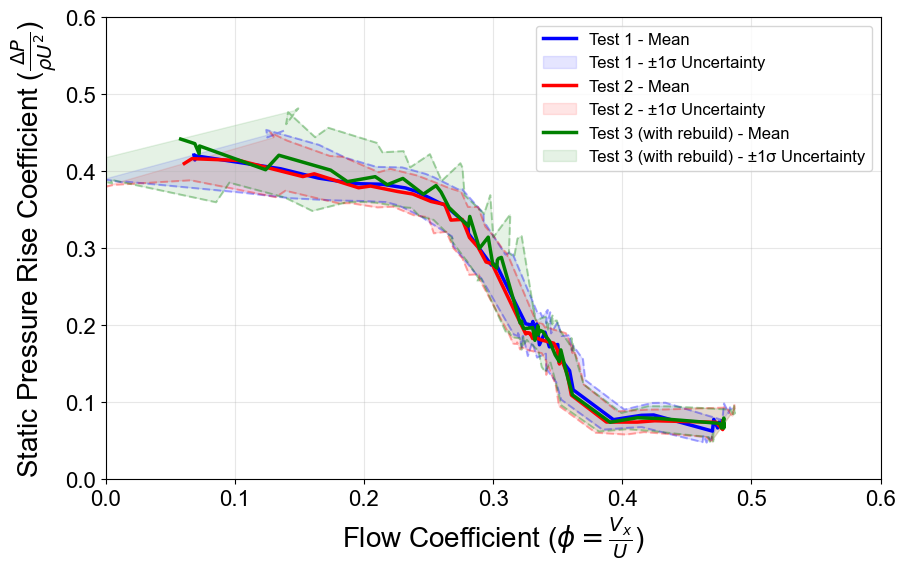

In [130]:
fig7, ax7 = plt.subplots(1, 1, figsize=(10, 6))

colours_all = ['b', 'r', 'g']

for idx, data in enumerate(fan_results):
    # Sort by flow coefficient
    sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
    flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
    prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
    prise_err_sorted = data['pressure_rise_coefficient_stddev'].values[sorted_indices]
    flow_err_sorted = data['flow_coefficient_stddev'].values[sorted_indices]
    
    # Plot main line
    ax7.plot(flow_sorted, prise_sorted, color=colours_all[idx], linewidth=2.5, label=f'{labels[idx]} - Mean', zorder=3)
    
    # Create Pareto front envelope considering both x and y uncertainties
    upper_flow = flow_sorted + flow_err_sorted
    upper_prise = prise_sorted + prise_err_sorted
    lower_flow = flow_sorted - flow_err_sorted
    lower_prise = prise_sorted - prise_err_sorted
    
    # Plot uncertainty envelope as dotted lines
    ax7.plot(upper_flow, upper_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    ax7.plot(lower_flow, lower_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    
    # Create filled region for the uncertainty envelope
    flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
    prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
    ax7.fill(flow_envelope, prise_envelope, alpha=0.1, color=colours_all[idx], label = f'{labels[idx]} - ±1σ Uncertainty')

ax7.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax7.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax7.set_ylim(0, 0.6)
ax7.set_xlim(0, 0.6)
ax7.grid(alpha=0.3)
ax7.legend(fontsize=12)
fig7.savefig("presentation/all_tests_performance_curves.svg", bbox_inches='tight')
plt.show()

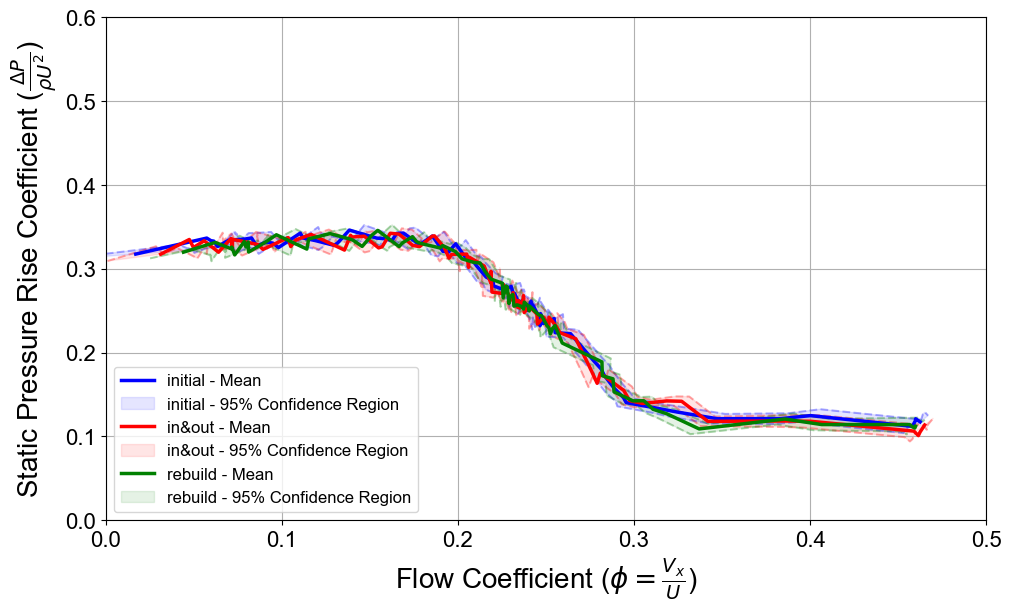

In [11]:
fig8, ax8 = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')

colours_all = ['b', 'r', 'g']

for idx, data in enumerate(fan_results):
    # Sort by flow coefficient
    sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
    flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
    prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
    prise_err_sorted = data['prisecoeff_confidence'].values[sorted_indices]
    flow_err_sorted = data['flowcoeff_confidence'].values[sorted_indices]
    
    # Plot main line
    ax8.plot(flow_sorted, prise_sorted, color=colours_all[idx], linewidth=2.5, label=f'{labels[idx]} - Mean', zorder=3)
    # ax8.scatter(flow_sorted, prise_sorted, color=colours_all[idx], marker='x', label=f'{labels[idx]} - Mean')
    
    # Create Pareto front envelope considering both x and y uncertainties
    upper_flow = flow_sorted + flow_err_sorted
    upper_prise = prise_sorted + prise_err_sorted
    lower_flow = flow_sorted - flow_err_sorted
    lower_prise = prise_sorted - prise_err_sorted
    
    # Plot uncertainty envelope as dotted lines
    ax8.plot(upper_flow, upper_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    ax8.plot(lower_flow, lower_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    
    # Create filled region for the uncertainty envelope
    flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
    prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
    ax8.fill(flow_envelope, prise_envelope, alpha=0.1, color=colours_all[idx], label = f'{labels[idx]} - 95% Confidence Region')

ax8.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax8.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax8.set_ylim(0,0.6)
ax8.set_xlim(0, 0.5)
ax8.grid()
ax8.legend(loc='lower left')
# fig8.savefig("report/all_tests_performance_curves_95confidence_3test.svg", bbox_inches='tight')
plt.show()

In [10]:
## aero power = pressure rise*volumetric flow rate
for d in fan_results:
    aero_power = d['dp_stage_mean']*d['mflow_mean']/d['rho_mean']
    d['aero_power_mean'] = aero_power*1000
    d['efficiency'] = aero_power/d['power_mean']*1000

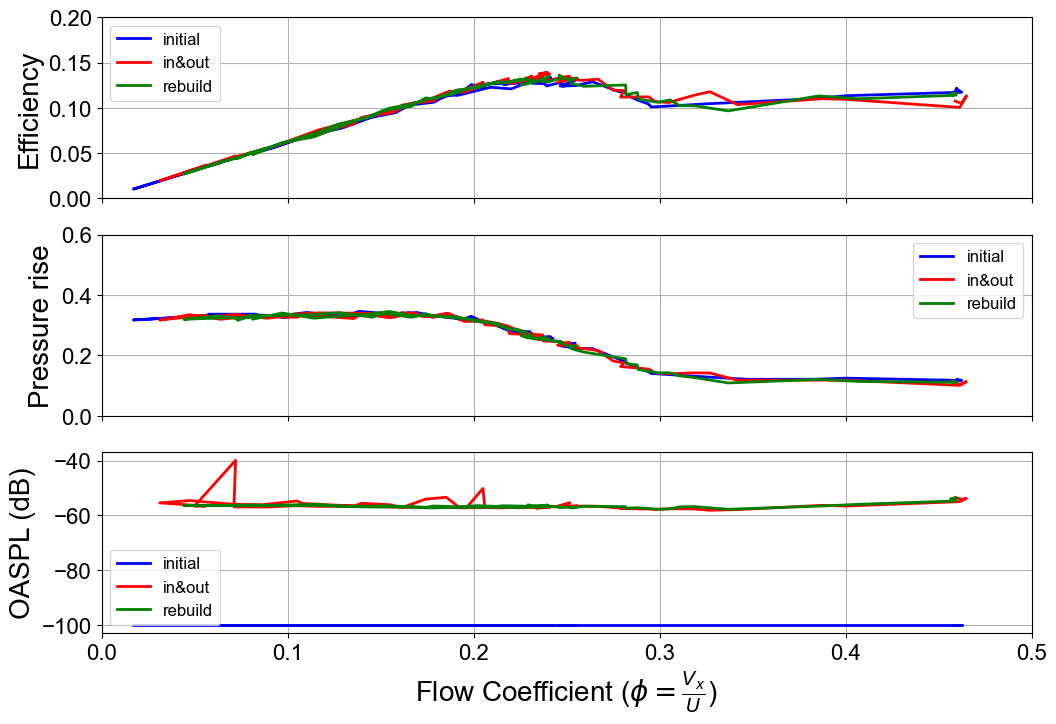

In [12]:
fig9,(ax9,ax91, ax92) = plt.subplots(3,1,figsize=(12,8), sharex=True)
# ax91 = ax9.sharex(ax9)
for i, r in enumerate(fan_results):
        ax9.plot(fan_results[i]['flow_coefficient_mean'], fan_results[i]['efficiency_mean'], color=colours[i],label = labels[i])
        ax91.plot(fan_results[i]['flow_coefficient_mean'], fan_results[i]['pressure_rise_coefficient_mean'], color=colours[i],label = labels[i])
        ax92.plot(fan_results[i]['flow_coefficient_mean'], fan_results[i]['oaspl'], color=colours[i],label = labels[i])
ax92.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax9.set_ylabel("Efficiency")
ax91.set_ylabel("Pressure rise")
ax92.set_ylabel("OASPL (dB)")
ax9.grid()
ax91.grid()
ax92.grid()
ax9.set_ylim(0,0.2)
ax91.set_ylim(0,0.6)
ax9.set_xlim(0,0.5)
ax9.legend()
ax91.legend()
ax92.legend()
fig9.savefig("meetings/chics_multi_test.svg", bbox_inches='tight')
plt.show()

In [44]:
copy_results = fan_results[2].copy()

In [45]:
mask = copy_results['dp_venturi_mean']<0
copy_results.loc[mask,'flow_coefficient_mean'] *= -1
copy_results.loc[mask, 'efficiency'] *= -1

In [ ]:
x = 0.5*copy_results['rho_mean']*(copy_results['axvelocity_mean']**2)
copy_results['dp_stage_static'] = copy_results['dp_stage_mean']-0.5*copy_results['rho_mean']*(copy_results['axvelocity_mean']**2)
print(x.head())
print(y.head())
print(copy_results['pressure_rise_coefficient_mean'].head())

0    7.425103
1    7.559616
2    7.606696
3    7.496843
4    5.609181
dtype: float64
0    3.084897
1    2.710384
2    3.283304
3    3.003157
4    5.530819
dtype: float64
0    0.105461
1    0.103307
2    0.109446
3    0.105228
4    0.112021
Name: pressure_rise_coefficient_mean, dtype: float64


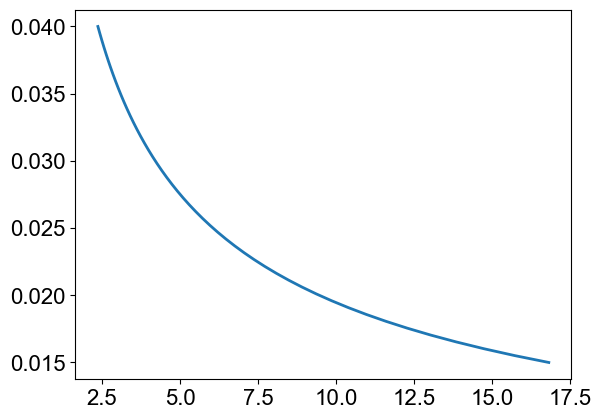

In [25]:
r = np.linspace(0.015, 0.04,50)
r_mid = 0.0275
vtheta_mid = 5
vortex_exponent = -2
vtheta = vtheta_mid * (r/r_mid)**vortex_exponent
plt.plot(vtheta, r)
plt.show()